# Análise Exploratória Inicial — Discursos dos Presidentes do Brasil

Este notebook inaugura o projeto **Brazil Presidents' Speeches Analysis**. O objetivo aqui é **carregar os dados**, **entender sua estrutura** e realizar uma **análise exploratória básica (EDA)** sobre os discursos.

## Configuração Inicial:

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

## Carregando discursos:

In [66]:
query = """
SELECT presidente, n_par, par
FROM speeches;
"""

df = pd.read_sql(query, engine)
df.head()

,presidente,n_par,par
0,Marechal Deodoro da Fonseca,1,"Concidadãos – O povo, o exército e a armada nacional, em perfeita comunhão de sentimentos com os nossos concidadãos ..."
1,Marechal Deodoro da Fonseca,2,"Como resultado imediato desta revolução nacional, de caráter essencialmente patriótico, acaba de ser instituído um g..."
2,Marechal Deodoro da Fonseca,3,"Para comporem esse governo, enquanto a nação soberana, pelos seus órgãos competentes, não proceder à escolha do gove..."
3,Marechal Deodoro da Fonseca,4,"Concidadãos – O governo provisório, simples agente temporário da soberania nacional, é o governo da paz, da liberdad..."
4,Marechal Deodoro da Fonseca,5,No uso das atribuições e faculdades extraordinárias de que se acha investido para a defesa da integridade da pátria ...


## Visão geral do dataset:

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   presidente  1540 non-null   object
 1   n_par       1540 non-null   int64 
 2   par         1540 non-null   object
dtypes: int64(1), object(2)
memory usage: 36.2+ KB


## Palavras mais usadas:

In [68]:
query = """
SELECT palavra, count(*) AS ocur
FROM (
         SELECT presidente,
             n_par,
             unnest(string_to_array(lower(regexp_replace(par, '[^a-zA-Záéíóúãõçü ]', '', 'g')), ' ')) AS palavra
         FROM speeches
) AS t
WHERE palavra != ''
GROUP BY palavra
ORDER BY ocur DESC;
"""

df = pd.read_sql(query, engine)
df.head(10)

,palavra,ocur
0,de,3414
1,e,3106
2,a,2921
3,que,2206
4,o,2052
5,do,1441
6,da,1427
7,para,873
8,os,817
9,em,737


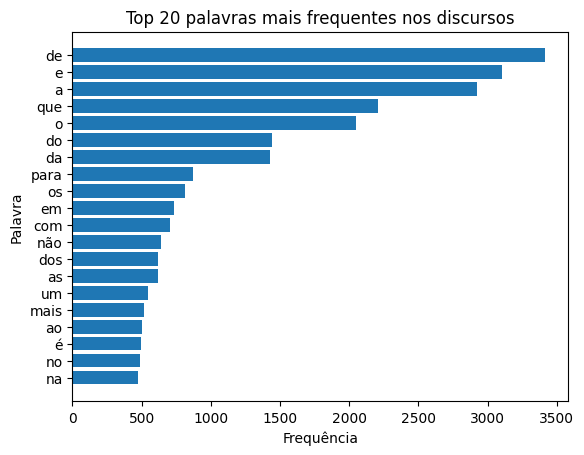

In [69]:
def plot_top_words(df, title):
    plt.figure()
    plt.barh(df['palavra'], df['ocur'])
    plt.xlabel("Frequência")
    plt.ylabel("Palavra")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

df_top = df.head(20)

plot_top_words(df.head(20),"Top 20 palavras mais frequentes nos discursos")

Após a remoção de stopwords, o corpus foi reduzido principalmente a substantivos, adjetivos, verbos e nomes próprios, permitindo uma análise mais semântica do discurso.

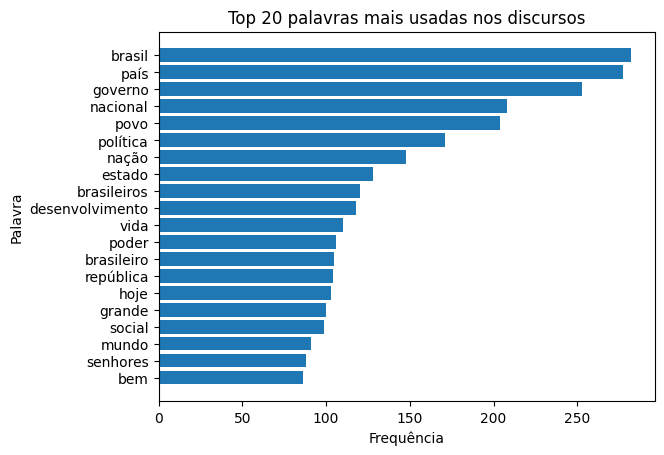

In [70]:
STOPWORDS_PT = {
    # Artigos
    "a", "o", "as", "os", "um", "uma", "uns", "umas",

    # Preposições
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "pelo", "pela", "pelos", "pelas",
    "para", "com", "sem", "sobre", "entre", "até", "após", "desde",

    # Pronomes
    "que", "quem", "qual", "quais",
    "se", "sua", "seu", "suas", "seus", "eu",
    "lhe", "lhes", "me", "te", "nós", "vos",
    "este", "esta", "estes", "estas",
    "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",

    # Conjunções
    "e", "ou", "mas", "porém", "todavia", "contudo",
    "porque", "pois", "logo", "portanto", "entretanto",

    # Advérbios funcionais
    "não", "sim", "já", "ainda", "sempre", "nunca",
    "muito", "pouco", "mais", "menos", "tão", "como",

    # Verbos auxiliares / muito frequentes
    "ser", "é", "era", "são", "foi", "foram",
    "estar", "está", "estão", "estava",
    "ter", "tem", "têm", "tinha",
    "haver", "há",

    # Outros conectivos comuns
    "ao", "à", "às", "aos",
    "isso", "isto", "aquilo",

    # Outros palavras obsoletas
    "todos", "todas", "nossa", "nosso", "meu", "s", "minha",
    "também", "só", "nossos", "nossas", "cada", "será", "assim", "mesmo"
}

df_clean = df[~df["palavra"].isin(STOPWORDS_PT)]

plot_top_words(df_clean.head(20),"Top 20 palavras mais usadas nos discursos")

A frequência do termo ‘Deus’ nos discursos de posse reflete mudanças na relação entre Estado, religião e retórica política ao longo da história republicana brasileira.

In [75]:
query = """
SELECT presidente, COUNT(*) AS total_deus
FROM (
    SELECT
        presidente,
        unnest(string_to_array(lower(regexp_replace(par, '[^a-zA-Záéíóúãõçü ]', '', 'g')),' ')
        ) AS palavra
    FROM speeches
) AS t
WHERE palavra = 'deus'
GROUP BY presidente
ORDER BY total_deus DESC;
"""

df_deus = pd.read_sql(query, engine)
df_deus.head(20)

,presidente,total_deus
0,Luiz Inácio Lula da Silva 2,7
1,Jair Bolsonaro,6
2,General Emílio Garrastazu Médici,4
3,General João Figueiredo,3
4,Luiz Inácio Lula da Silva 1,2
5,Luiz Inácio Lula da Silva 3,2
6,Dilma Rousseff 1,2
7,Marechal Castelo Branco,1
8,Marechal Costa e Silva,1
9,Michel Temer,1
